In [ ]:
import pandas as pd
import pandas_datareader.data as web
import datetime
import matplotlib.pyplot as plt

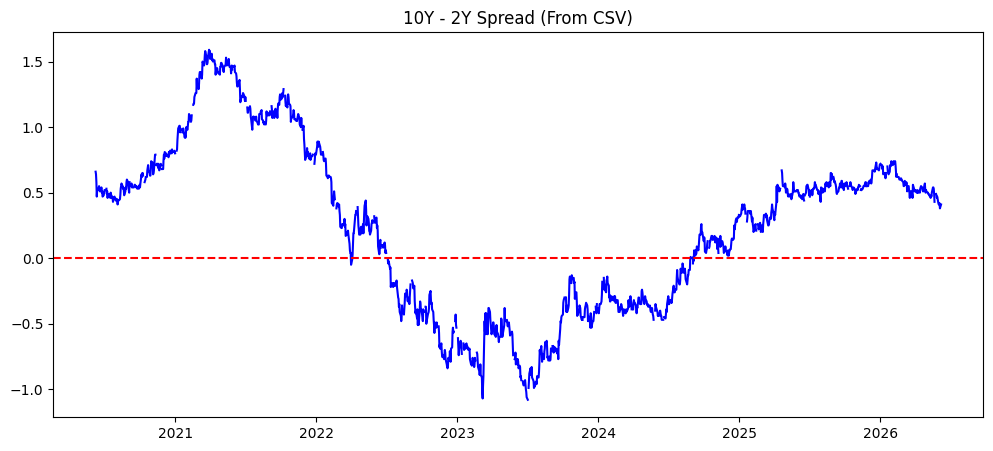

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sample_data/T10Y2Y.csv', parse_dates=['observation_date'], index_col='observation_date')

df = df[df['T10Y2Y'] != '.']
df['T10Y2Y'] = df['T10Y2Y'].astype(float)

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['T10Y2Y'], color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("10Y - 2Y Spread (From CSV)")
plt.show()

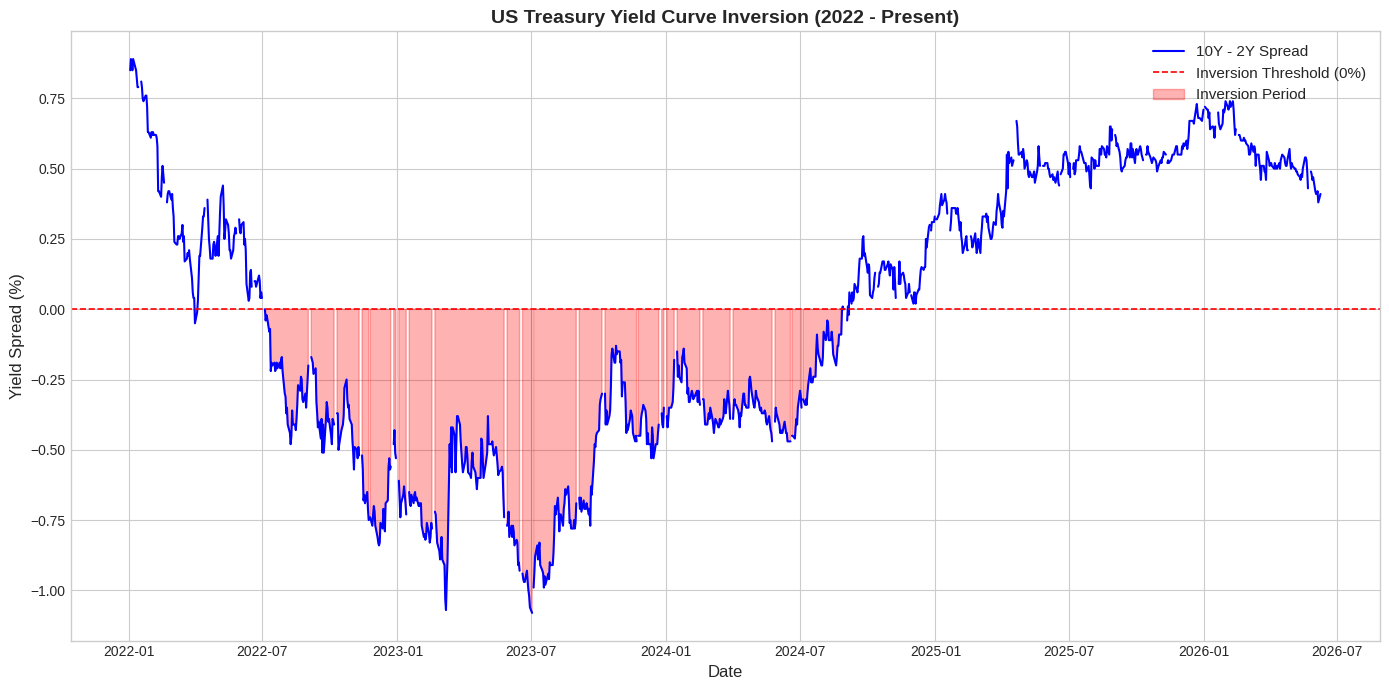

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sample_data/T10Y2Y.csv', parse_dates=['observation_date'], index_col='observation_date')

df = df[df['T10Y2Y'] != '.']

df['T10Y2Y'] = df['T10Y2Y'].astype(float)

df_filtered = df.loc['2022-01-01':]

plt.figure(figsize=(14, 7))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(df_filtered.index, df_filtered['T10Y2Y'], label='10Y - 2Y Spread', color='blue', linewidth=1.5)

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.2, label='Inversion Threshold (0%)')

plt.fill_between(df_filtered.index, df_filtered['T10Y2Y'], 0,
                 where=(df_filtered['T10Y2Y'] < 0), color='red', alpha=0.3, label='Inversion Period')

plt.title('US Treasury Yield Curve Inversion (2022 - Present)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Yield Spread (%)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

In [33]:
from google.colab import files
import pandas as pd
upload = files.upload()
data = pd.read_csv("FEDFUNDS.csv")

Saving FEDFUNDS.csv to FEDFUNDS.csv


====== 2022年至今：處理缺失值前 (Null values before filling) ======
T10Y2Y      4
FEDFUNDS    0
dtype: int64
====== 2022年至今：處理缺失值後 (Null values after filling) ======
T10Y2Y      0
FEDFUNDS    0
dtype: int64

====== 2022年至今：Fed利率與美債利差相關性矩陣 ======
            T10Y2Y  FEDFUNDS
T10Y2Y    1.000000 -0.429367
FEDFUNDS -0.429367  1.000000

💡 統計洞察：在 2022 年至今的升息循環中，兩者相關係數為 -0.43


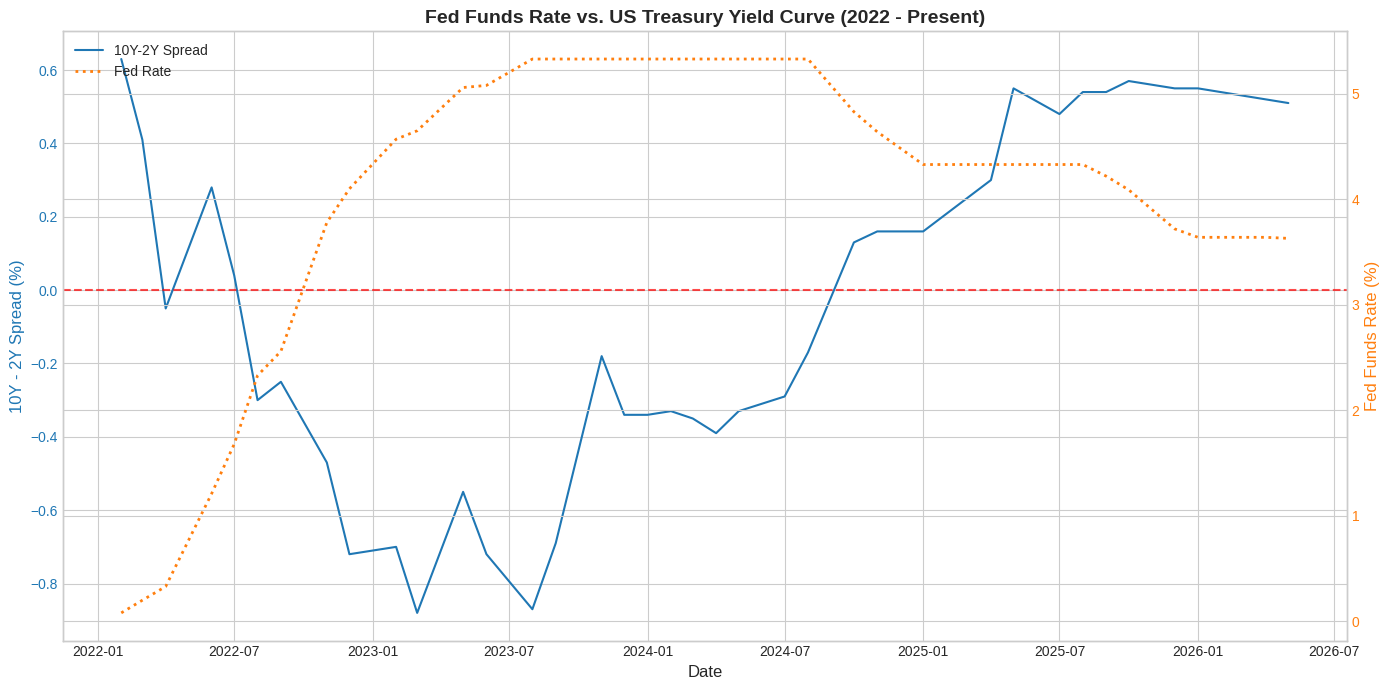

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

df_fed = data.copy()

df_fed = df_fed[df_fed['FEDFUNDS'] != '.']
df_fed['FEDFUNDS'] = df_fed['FEDFUNDS'].astype(float)

df_spread.index = pd.to_datetime(df_spread.index)
df_fed.index = pd.to_datetime(df_fed['observation_date'])
df_macro = pd.merge(df_spread, df_fed[['FEDFUNDS']], left_index=True, right_index=True, how='inner')

df_macro_filtered = df_macro.loc['2022-01-01':]

print("====== 2022年至今：處理缺失值前 (Null values before filling) ======")
print(df_macro_filtered.isnull().sum())

df_macro_filtered = df_macro_filtered.ffill().bfill()

print("====== 2022年至今：處理缺失值後 (Null values after filling) ======")
print(df_macro_filtered.isnull().sum())
print("===================================================\n")


matrix = df_macro_filtered.corr()

print("====== 2022年至今：Fed利率與美債利差相關性矩陣 ======")
print(matrix)
print("===================================================\n")

corr_value = matrix.loc['T10Y2Y', 'FEDFUNDS']
print(f"💡 統計洞察：在 2022 年至今的升息循環中，兩者相關係數為 {corr_value:.2f}")

fig, ax1 = plt.subplots(figsize=(14, 7))
plt.style.use('seaborn-v0_8-whitegrid')

color = 'tab:blue'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('10Y - 2Y Spread (%)', color=color, fontsize=12)
ax1.plot(df_macro_filtered.index, df_macro_filtered['T10Y2Y'], color=color, linewidth=1.5, label='10Y-2Y Spread')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Fed Funds Rate (%)', color=color, fontsize=12)
ax2.plot(df_macro_filtered.index, df_macro_filtered['FEDFUNDS'], color=color, linewidth=2, linestyle=':', label='Fed Rate')
ax2.tick_params(axis='y', labelcolor=color)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Fed Funds Rate vs. US Treasury Yield Curve (2022 - Present)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()